# 03 — Retroproyección y FBP Ramp

## Objetivo

Separar la retroproyección del filtrado y verificar la reconstrucción de referencia.

**Alcance:** Hito 1 actualizado.

## Datos utilizados

Par TCIA C095/1-250 de `config/default.json`. Las rutas DICOM se configuran en ese JSON; por defecto se usan data/sdct y data/ldct. Cada notebook se ejecuta de forma independiente.

## Procedimiento

Reutilizar la retroproyección lineal explícita del experimento Fourier. Contrastar su rama sin filtro con iradon(filter_name=None); reconstruir después con Ramp.

**Procedencia:** comparar_fourier_tcia.py: retroproyectar; Hito-1/reproducir.py: calcular; descomposición didáctica documentada; detalles en `../REFACTOR_MAP.md`.

## Parámetros

In [1]:
from pathlib import Path
import os
import sys
sys.dont_write_bytecode = True
start = Path.cwd().resolve()
root = next((p for p in (start, *start.parents) if (p / 'src/config.py').is_file() and (p / 'config/default.json').is_file()), None)
if root is None and (start / 'hito1-mini-tesis/src').is_dir():
    root = start / 'hito1-mini-tesis'
if root is None:
    raise RuntimeError('Abre Jupyter desde la raíz del repositorio o su carpeta notebooks.')
sys.path.insert(0, str(root))
os.environ['MPLCONFIGDIR'] = str(root / 'outputs/.matplotlib')
import numpy as np
import matplotlib.pyplot as plt
from src.config import load_config, output_path
from src.experiments import prepare_pair
from src.visualization import show_table, finish_figure
config = load_config()
show_table([{key: config[key] for key in ('num_angles', 'sigma_gaussian', 'seed', 'filter_name', 'visual_amplification')}])

num_angles,sigma_gaussian,seed,filter_name,visual_amplification
512,1,42,ramp,5


## Resultados

In [2]:
from src.radon import generate_sinogram
from src.reconstruction import backproject, reconstruct_fbp
from src.metrics import error_metrics
from skimage.transform import iradon
pair = prepare_pair(config)
sino = generate_sinogram(pair['sdct'], pair['theta'])
bp = backproject(sino, pair['theta'], pair['sdct'].shape[0])
bp_reference = iradon(sino, theta=pair['theta'], output_size=pair['sdct'].shape[0], filter_name=None, circle=False)
np.testing.assert_allclose(bp, bp_reference, atol=1e-10, rtol=1e-12)
fbp = reconstruct_fbp(sino, pair['theta'], output_size=pair['sdct'].shape[0], filter_name='ramp')

La BP sin filtro usa su propia barra porque su amplitud es diferente. La entrada y FBP comparten [0,1]. Esta descomposición didáctica no reemplaza la FBP de las figuras del informe.

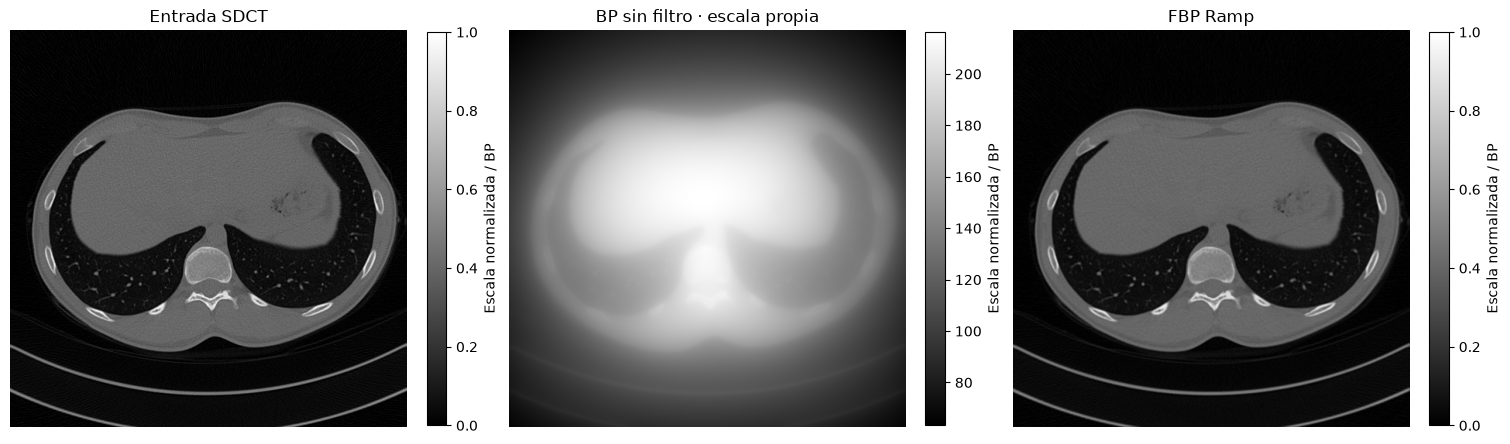

MAE_HU,RMSE_HU,MAX_HU
22.9248,31.8897,355.433


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout='constrained')
for ax, image, label, limits in zip(axes, (pair['sdct'], bp, fbp),
        ('Entrada SDCT', 'BP sin filtro · escala propia', 'FBP Ramp'), ((0, 1), (float(bp.min()), float(bp.max())), (0, 1))):
    im = ax.imshow(image, cmap='gray', vmin=limits[0], vmax=limits[1])
    ax.set_title(label)
    ax.axis('off')
    fig.colorbar(im, ax=ax, shrink=0.8, label='Escala normalizada / BP')
finish_figure(fig, output_path('figures', '03_bp_fbp.png'))
error_hu = (pair['sdct'] - fbp) * pair['scale'].range
show_table([error_metrics(error_hu, np.zeros_like(error_hu), suffix='_HU')])

## Observaciones

El filtrado cambia la retroproyección y su escala. La discrepancia FBP no es cero aun sin ruido añadido: contiene efectos de discretización, interpolación y filtrado. Las reconstrucciones mantienen el overshoot.